# 05 — Train Mental-Health Classifiers (Low et al. methodology)

Trains three binary LinearSVC classifiers following Low et al. (2020) *"Natural Language Processing for Mental Health Interventions"*:
- **anxiety_clf**: r/anxiety (positive) vs. control subreddits (negative)
- **depression_clf**: r/depression (positive) vs. control subreddits (negative)
- **stress_clf**: r/stress (positive) vs. control subreddits (negative)

**Training data**: pulled from Arctic Shift (same API used in notebook 04), using posts from
2022-01-01 to 2023-07-31 (pre-dating our study window, no data leakage).

**Features**: TF-IDF on unigrams + bigrams (max 50k features, sublinear_tf=True).

**Score applied to corpus**: `decision_function` output (continuous), not binary prediction.
Higher = more similar to the positive (mental-health) class.

**Outputs**:
- `clf_anxiety.joblib`, `clf_depression.joblib`, `clf_stress.joblib` (trained models + vectorizer)
- `scored_corpus_v2.parquet` — adds `anx_score`, `dep_score`, `str_score`, `mh_score` (mean of 3)
- `user_weekly_scores_v2.parquet` — weekly aggregations on `mh_score`

**Runtime**: ~30 min (API pulls ~15 min + training ~2 min + scoring ~5 min)

In [14]:
import pandas as pd
import numpy as np
import requests
import time
import json
import joblib
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.utils import shuffle

ROOT     = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'processed'
RAW_DIR  = ROOT / 'data' / 'raw'
FIG_DIR  = ROOT / 'figures'
MODEL_DIR = ROOT / 'models'

BASE_URL    = 'https://arctic-shift.photon-reddit.com'
RATE_LIMIT  = 0.4   # seconds between requests

# Training window: before our study period to avoid data leakage
TRAIN_AFTER  = '2022-01-01'
TRAIN_BEFORE = '2023-07-31'

# Posts per subreddit to fetch (balanced classes)
N_PER_SUB = 2000

TRAIN_DATA_PATH = DATA_DIR / 'training_data_raw.parquet'
print('Setup complete')

Setup complete


## 1) Pull training data from Arctic Shift

In [15]:
# Positive subreddits (mental health) — same as Low et al. 2020
MH_SUBS = ['anxiety', 'depression', 'stress']

# Control subreddits: avoid very large subs (r/AskReddit times out per API docs)
CTRL_SUBS = ['personalfinance', 'learnprogramming', 'todayilearned', 'careerguidance']

session = requests.Session()
session.headers.update({'User-Agent': 'CS598-research/1.0 (uiuc; gradadmissions study)'})

def fetch_posts_for_sub(subreddit, n=2000, after=TRAIN_AFTER, before=TRAIN_BEFORE):
    """Paginate Arctic Shift /api/posts/search to collect n posts from a subreddit.

    API docs: https://github.com/ArthurHeitmann/arctic_shift/blob/master/api/README.md
    Endpoint: /api/posts/search
    Pagination: use created_utc of last record as next `after` value (epoch seconds accepted).
    """
    posts = []
    after_ts = after
    while len(posts) < n:
        params = {
            'subreddit': subreddit,
            'after':     after_ts,
            'before':    before,
            'limit':     'auto',   # returns 100-1000 depending on server capacity
            'sort':      'asc',    # sort by created_utc ascending
        }
        try:
            r = session.get(f'{BASE_URL}/api/posts/search', params=params, timeout=30)
            rl_remaining = r.headers.get('X-RateLimit-Remaining')

            if r.status_code == 429:
                rl_reset = r.headers.get('X-RateLimit-Reset')
                wait = 10
                if rl_reset:
                    try: wait = max(1, float(rl_reset) - time.time()) + 1
                    except: pass
                print(f'    Rate limited — waiting {wait:.0f}s')
                time.sleep(wait)
                continue

            if r.status_code != 200:
                print(f'    HTTP {r.status_code} for r/{subreddit}: {r.text[:300]}')
                break

            data = r.json().get('data', [])
            if not data:
                break

            for p in data:
                text = ' '.join(filter(None, [p.get('title', ''), p.get('selftext', '')])).strip()
                if len(text) > 20 and text not in ('[deleted]', '[removed]'):
                    posts.append({
                        'text':        text,
                        'subreddit':   subreddit,
                        'created_utc': p.get('created_utc', ''),
                    })

            # Pagination: advance `after` to created_utc of last record (epoch seconds)
            last_ts = data[-1].get('created_utc', '')
            if not last_ts or last_ts == after_ts:
                break   # no new data
            after_ts = last_ts

            # Dynamic rate limiting per X-RateLimit-Remaining header
            if rl_remaining:
                try:
                    rem = int(rl_remaining)
                    if rem < 5:    time.sleep(2.0)
                    elif rem < 20: time.sleep(0.8)
                    else:          time.sleep(RATE_LIMIT)
                except:
                    time.sleep(RATE_LIMIT)
            else:
                time.sleep(RATE_LIMIT)

        except Exception as e:
            print(f'    Error: {e}')
            time.sleep(2)
            break

    return posts[:n]


if TRAIN_DATA_PATH.exists():
    print(f'Training data already cached at {TRAIN_DATA_PATH}')
    train_raw = pd.read_parquet(TRAIN_DATA_PATH)
    print(train_raw['subreddit'].value_counts())
else:
    all_records = []
    for sub in MH_SUBS + CTRL_SUBS:
        print(f'Fetching r/{sub}...')
        recs = fetch_posts_for_sub(sub, n=N_PER_SUB)
        all_records.extend(recs)
        print(f'  → {len(recs):,} posts collected')

    train_raw = pd.DataFrame(all_records)
    if len(train_raw) > 0:
        train_raw.to_parquet(TRAIN_DATA_PATH, index=False)
        print(f'\nSaved {len(train_raw):,} training records')
        print(train_raw['subreddit'].value_counts())
    else:
        print('No data collected — check API response above')

Fetching r/anxiety...
  → 2,000 posts collected
Fetching r/depression...
  → 2,000 posts collected
Fetching r/stress...
  → 2,000 posts collected
Fetching r/personalfinance...
  → 2,000 posts collected
Fetching r/learnprogramming...
  → 2,000 posts collected
Fetching r/todayilearned...
  → 2,000 posts collected
Fetching r/careerguidance...
  → 2,000 posts collected

Saved 14,000 training records
subreddit
anxiety             2000
depression          2000
stress              2000
personalfinance     2000
learnprogramming    2000
todayilearned       2000
careerguidance      2000
Name: count, dtype: int64


## 2) Train classifiers (one per mental-health class)

In [16]:
# Build combined control pool (all control posts)
ctrl_df = train_raw[train_raw['subreddit'].isin(CTRL_SUBS)].copy()
print(f'Control pool: {len(ctrl_df):,} posts')

classifiers = {}  # will hold {name: fitted_pipeline}

for mh_sub in MH_SUBS:
    print(f'\n--- Training {mh_sub} classifier ---')
    pos_df = train_raw[train_raw['subreddit'] == mh_sub].copy()
    
    # Sample equal number of controls (balanced classes)
    n_pos = len(pos_df)
    neg_df = ctrl_df.sample(n=min(n_pos, len(ctrl_df)), random_state=42)
    
    pos_df['label'] = 1
    neg_df['label'] = 0
    
    combined = pd.concat([pos_df, neg_df], ignore_index=True)
    combined = shuffle(combined, random_state=42)
    
    X = combined['text'].tolist()
    y = combined['label'].values
    
    print(f'  Positive (r/{mh_sub}): {n_pos:,}  |  Negative (control): {len(neg_df):,}')
    
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(
            ngram_range=(1, 2),
            max_features=50_000,
            sublinear_tf=True,
            min_df=3,
            strip_accents='unicode',
            analyzer='word',
        )),
        ('clf', LinearSVC(C=1.0, max_iter=2000, class_weight='balanced')),
    ])
    
    # 5-fold cross-validation
    cv_scores = cross_val_score(pipe, X, y, cv=StratifiedKFold(5), scoring='f1', n_jobs=-1)
    print(f'  CV F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
    
    # Fit on full training set
    pipe.fit(X, y)
    classifiers[mh_sub] = pipe
    
    # Save model
    model_path = MODEL_DIR / f'clf_{mh_sub}.joblib'
    joblib.dump(pipe, model_path)
    print(f'  Saved → {model_path.name}')

print('\nAll classifiers trained.')

Control pool: 8,000 posts

--- Training anxiety classifier ---
  Positive (r/anxiety): 2,000  |  Negative (control): 2,000
  CV F1: 0.883 ± 0.010
  Saved → clf_anxiety.joblib

--- Training depression classifier ---
  Positive (r/depression): 2,000  |  Negative (control): 2,000
  CV F1: 0.884 ± 0.009
  Saved → clf_depression.joblib

--- Training stress classifier ---
  Positive (r/stress): 2,000  |  Negative (control): 2,000
  CV F1: 0.938 ± 0.006
  Saved → clf_stress.joblib

All classifiers trained.


## 3) Quick evaluation on held-out test sample

In [17]:
from sklearn.model_selection import train_test_split

for mh_sub in MH_SUBS:
    pipe = classifiers[mh_sub]
    pos_df = train_raw[train_raw['subreddit'] == mh_sub].copy()
    neg_df = ctrl_df.sample(n=len(pos_df), random_state=42)
    pos_df['label'] = 1; neg_df['label'] = 0
    combined = shuffle(pd.concat([pos_df, neg_df], ignore_index=True), random_state=99)
    
    X_tr, X_te, y_tr, y_te = train_test_split(
        combined['text'].tolist(), combined['label'].values,
        test_size=0.2, random_state=99, stratify=combined['label'].values
    )
    pipe_eval = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=50_000,
                                  sublinear_tf=True, min_df=3)),
        ('clf', LinearSVC(C=1.0, max_iter=2000, class_weight='balanced')),
    ])
    pipe_eval.fit(X_tr, y_tr)
    y_pred = pipe_eval.predict(X_te)
    print(f'\n=== {mh_sub} (80/20 split) ===')
    print(classification_report(y_te, y_pred, target_names=['control', mh_sub]))


=== anxiety (80/20 split) ===
              precision    recall  f1-score   support

     control       0.94      0.76      0.84       400
     anxiety       0.80      0.95      0.87       400

    accuracy                           0.86       800
   macro avg       0.87      0.86      0.85       800
weighted avg       0.87      0.86      0.85       800


=== depression (80/20 split) ===
              precision    recall  f1-score   support

     control       0.95      0.75      0.84       400
  depression       0.79      0.96      0.87       400

    accuracy                           0.85       800
   macro avg       0.87      0.85      0.85       800
weighted avg       0.87      0.85      0.85       800


=== stress (80/20 split) ===
              precision    recall  f1-score   support

     control       0.94      0.95      0.95       400
      stress       0.95      0.94      0.95       400

    accuracy                           0.95       800
   macro avg       0.95      0.95

## 4) Score the full gradadmissions corpus

In [18]:
print('Loading scored corpus...')
corpus = pd.read_parquet(DATA_DIR / 'scored_corpus.parquet')
print(f'  {len(corpus):,} records')

texts = corpus['clean_text'].fillna('').tolist()

for mh_sub in MH_SUBS:
    short = mh_sub[:3]  # anx, dep, str
    pipe = classifiers[mh_sub]
    print(f'Scoring {mh_sub}...')
    scores = pipe.decision_function(texts)
    # Normalize to [0,1] range using sigmoid-like transform for interpretability
    corpus[f'{short}_score'] = 1 / (1 + np.exp(-scores))
    print(f'  Mean {short}_score: {corpus[f"{short}_score"].mean():.4f}')

# Composite mental-health score: mean of three
corpus['mh_score'] = corpus[['anx_score', 'dep_score', 'str_score']].mean(axis=1)

print(f'\nComposite mh_score — mean: {corpus["mh_score"].mean():.4f}, std: {corpus["mh_score"].std():.4f}')
print(corpus[['anx_score', 'dep_score', 'str_score', 'mh_score']].describe().round(4))

Loading scored corpus...
  467,525 records
Scoring anxiety...
  Mean anx_score: 0.4164
Scoring depression...
  Mean dep_score: 0.4076
Scoring stress...
  Mean str_score: 0.4491

Composite mh_score — mean: 0.4244, std: 0.0812
         anx_score    dep_score    str_score     mh_score
count  467525.0000  467525.0000  467525.0000  467525.0000
mean        0.4164       0.4076       0.4491       0.4244
std         0.0849       0.0923       0.0852       0.0812
min         0.0869       0.0532       0.0915       0.0840
25%         0.3582       0.3446       0.3921       0.3699
50%         0.4132       0.4059       0.4480       0.4232
75%         0.4716       0.4688       0.5050       0.4776
max         0.9881       0.8527       0.8732       0.8302


In [19]:
# Sanity check: scores should differ by outcome label
print('mh_score by outcome label:')
print(corpus[corpus['outcome'] != 'Unknown'].groupby('outcome')['mh_score'].describe().round(4))

print('\nmh_score by sent_label (VADER):')
print(corpus.groupby('sent_label')['mh_score'].mean().round(4))

mh_score by outcome label:
              count    mean     std     min     25%     50%     75%     max
outcome                                                                    
Accepted    66970.0  0.4007  0.0838  0.1028  0.3444  0.3997  0.4556  0.7815
Rejected    12482.0  0.4514  0.0801  0.1724  0.3982  0.4500  0.5037  0.7779
Waitlisted   4350.0  0.4456  0.0735  0.1837  0.3965  0.4437  0.4927  0.7334

mh_score by sent_label (VADER):
sent_label
negative    0.4456
neutral     0.4191
positive    0.4199
Name: mh_score, dtype: float64


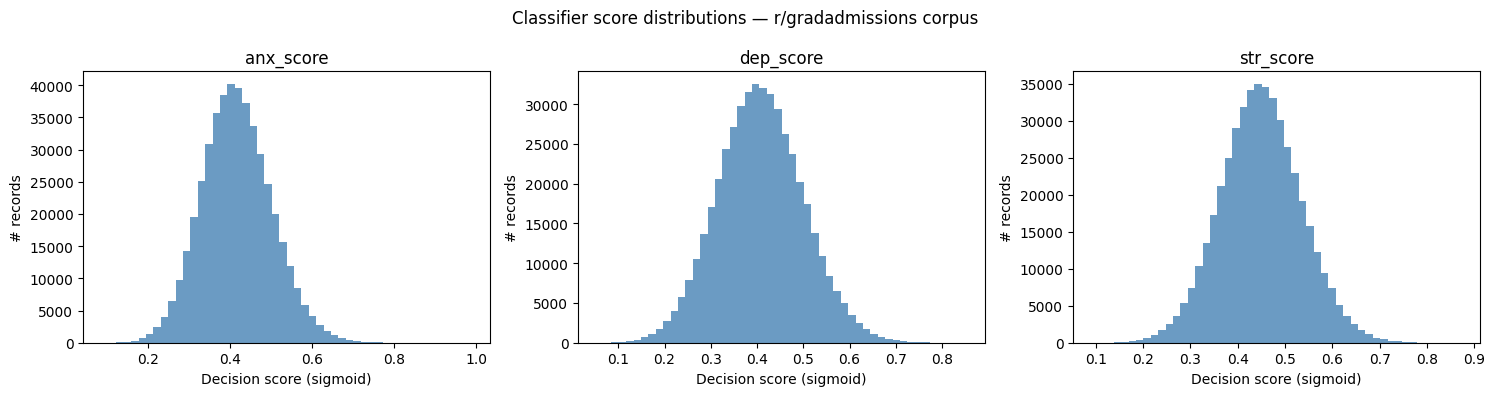

In [20]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['anx_score', 'dep_score', 'str_score']):
    axes[i].hist(corpus[col], bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel('Decision score (sigmoid)')
    axes[i].set_ylabel('# records')
plt.suptitle('Classifier score distributions — r/gradadmissions corpus')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_classifier_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 5) Save scored corpus v2 and user-weekly scores v2

In [21]:
# Save full scored corpus v2
out_v2 = DATA_DIR / 'scored_corpus_v2.parquet'
corpus.to_parquet(out_v2, index=False)
print(f'Saved {len(corpus):,} rows → {out_v2}')
print('New columns:', ['anx_score', 'dep_score', 'str_score', 'mh_score'])

Saved 467,525 rows → /media/ayush/F/Coding/CS598_Research_Project/pipeline/scored_corpus_v2.parquet
New columns: ['anx_score', 'dep_score', 'str_score', 'mh_score']


In [22]:
# Rebuild user_weekly_scores with mh_score as primary outcome
user_weekly_v2 = (
    corpus.groupby(['author', 'week'], sort=True)
    .agg(
        n_posts          = ('record_id',      'count'),
        mean_compound    = ('vader_compound',  'mean'),   # keep for comparison
        mean_distress    = ('distress_score',  'mean'),   # VADER-based (legacy)
        pct_negative     = ('is_negative',     'mean'),
        min_compound     = ('vader_compound',  'min'),
        mean_anx         = ('anx_score',       'mean'),
        mean_dep         = ('dep_score',       'mean'),
        mean_str         = ('str_score',       'mean'),
        mean_mh_score    = ('mh_score',        'mean'),   # PRIMARY outcome for DiD v2
        max_mh_score     = ('mh_score',        'max'),
    )
    .reset_index()
)

user_weekly_v2['week_dt'] = pd.to_datetime(
    user_weekly_v2['week'] + '-1', format='%G-W%V-%u', utc=True
)

out_path = DATA_DIR / 'user_weekly_scores_v2.parquet'
user_weekly_v2.to_parquet(out_path, index=False)
print(f'Saved {len(user_weekly_v2):,} user-week rows → {out_path}')
print(user_weekly_v2[['mean_mh_score', 'mean_anx', 'mean_dep', 'mean_str']].describe().round(4))

Saved 210,133 user-week rows → /media/ayush/F/Coding/CS598_Research_Project/pipeline/user_weekly_scores_v2.parquet
       mean_mh_score     mean_anx     mean_dep     mean_str
count    210133.0000  210133.0000  210133.0000  210133.0000
mean          0.4180       0.4102       0.4002       0.4436
std           0.0753       0.0777       0.0851       0.0790
min           0.0924       0.0956       0.0660       0.0915
25%           0.3714       0.3608       0.3464       0.3952
50%           0.4199       0.4103       0.4016       0.4454
75%           0.4654       0.4588       0.4541       0.4927
max           0.8285       0.8250       0.8101       0.8591


## 6) Correlation: mh_score vs. VADER (sanity check)

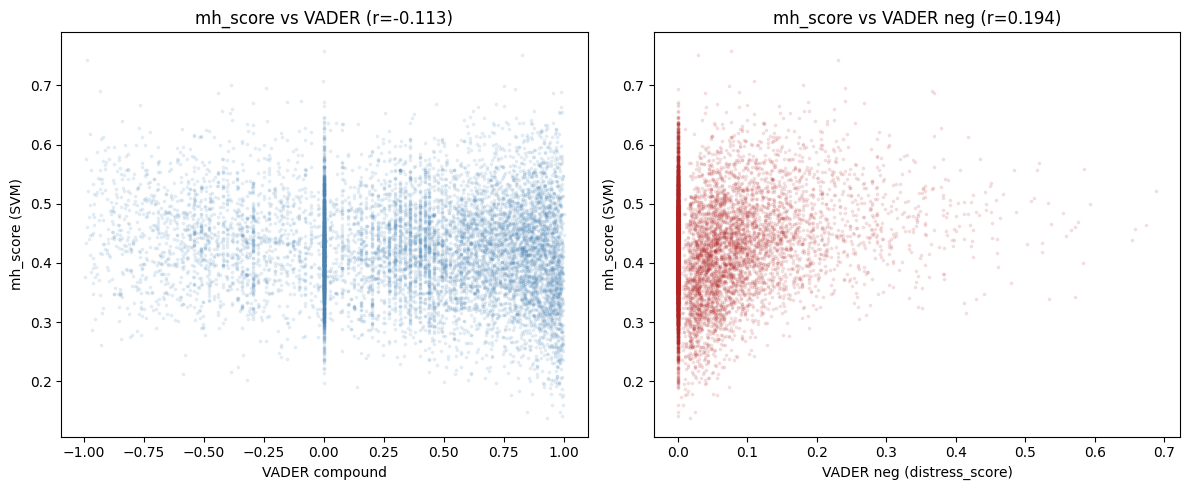

Pearson r (mh_score vs vader_compound): -0.1134
Pearson r (mh_score vs vader_neg):      0.1941


In [23]:
sample = corpus.sample(10_000, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(sample['vader_compound'], sample['mh_score'],
                alpha=0.1, s=3, color='steelblue')
axes[0].set_xlabel('VADER compound')
axes[0].set_ylabel('mh_score (SVM)')
corr = sample[['vader_compound', 'mh_score']].corr().iloc[0,1]
axes[0].set_title(f'mh_score vs VADER (r={corr:.3f})')

axes[1].scatter(sample['distress_score'], sample['mh_score'],
                alpha=0.1, s=3, color='firebrick')
axes[1].set_xlabel('VADER neg (distress_score)')
axes[1].set_ylabel('mh_score (SVM)')
corr2 = sample[['distress_score', 'mh_score']].corr().iloc[0,1]
axes[1].set_title(f'mh_score vs VADER neg (r={corr2:.3f})')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_score_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Pearson r (mh_score vs vader_compound): {corr:.4f}')
print(f'Pearson r (mh_score vs vader_neg):      {corr2:.4f}')